In [13]:
from pathlib import Path
import pandas as pd
import sys

PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# Your project imports
import util.read_price as read_price
from src.analysis.forecast_accuracy_IP import (
    evaluate_ip_deterministic,
    evaluate_ip_probabilistic,
    plot_det_horizon_metrics,
    plot_prob_coverage,
    plot_calibration_curve,
)

PROJECT_ROOT = Path.cwd().parent
DATA_DIR = PROJECT_ROOT / "Data"


In [14]:
# Load real prices (15-min)
ip_real = read_price.read_ip_real_prices(
    data_dir=DATA_DIR,
    freq="15min",
    keep_extra_columns=False,
    verbose=True,
)["Price"]

ip_real.index.min(), ip_real.index.max()


(Timestamp('2021-01-01 00:00:00'), Timestamp('2023-12-31 23:45:00'))

In [15]:
# Deterministic forecast 
ip_det = read_price.read_ip_forecast(
    model="QR",
    kind="deterministic",
    data_dir=DATA_DIR,
    freq="15min",
    verbose=True,
)



In [16]:
det_metrics = evaluate_ip_deterministic(
    ip_det,
    ip_real,
    dt=pd.Timedelta("15min"),   # explicit, recommended
    base_offset_steps=0,        # qh1 matches y at same timestamp
)
det_metrics


,MAE,RMSE,N
horizon,,,
1,71.109629,110.191133,37913
2,83.898362,122.240422,37913
3,89.094789,128.155748,37913
4,91.251881,130.819851,37913
5,94.687956,134.150410,37913
6,96.311343,136.097883,37913
7,97.000918,136.988817,37913
8,97.556721,137.816997,37913


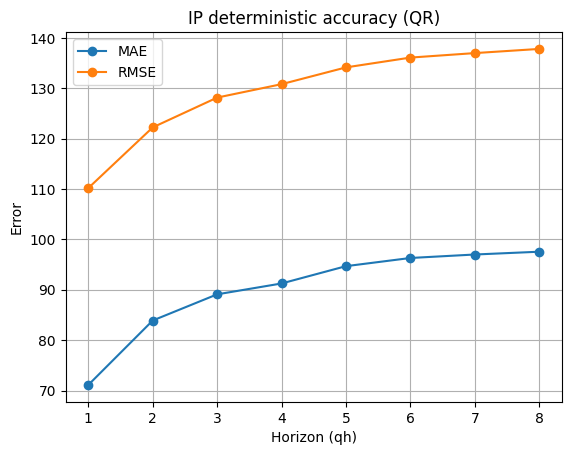

In [17]:
plot_det_horizon_metrics(det_metrics, title="IP deterministic accuracy (QR)")


In [18]:
# Probabilistic forecast (example: QR or LEAR depending on what you have)
ip_prob = read_price.read_ip_forecast(
    model="QR",
    kind="probabilistic",
    data_dir=DATA_DIR,
    freq="15min",
    verbose=True,
)



In [19]:
prob_out = evaluate_ip_probabilistic(
    ip_prob,
    ip_real,
    dt=pd.Timedelta("15min"),
    intervals=((0.01, 0.99), (0.05, 0.95),(0.1, 0.9), (0.2, 0.8), (0.3, 0.7), (0.4, 0.6)),
    base_offset_steps=0,
)

prob_out["coverage"]


,"[q0.01, q0.99]","[q0.05, q0.95]","[q0.1, q0.9]","[q0.2, q0.8]","[q0.3, q0.7]","[q0.4, q0.6]",N
horizon,,,,,,,
1,0.978714,0.919790,0.836019,0.644238,0.431356,0.219608,37913
2,0.980482,0.920080,0.840662,0.652177,0.448870,0.225068,37913
3,0.979400,0.918603,0.840767,0.654182,0.445916,0.222984,37913
4,0.979189,0.919052,0.839870,0.654208,0.444465,0.223063,37913
5,0.979005,0.919711,0.842587,0.659009,0.452826,0.233113,37913
6,0.978820,0.919922,0.843378,0.659220,0.456572,0.237254,37913
7,0.978081,0.920449,0.842903,0.659932,0.457759,0.238282,37913
8,0.978609,0.920608,0.842798,0.660328,0.458260,0.239443,37913


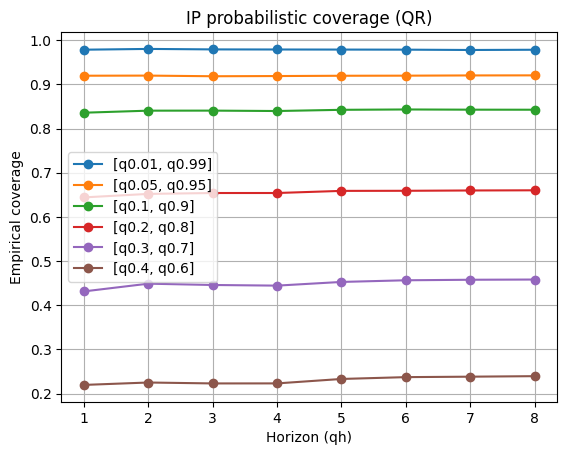

In [20]:
plot_prob_coverage(prob_out["coverage"], title="IP probabilistic coverage (QR)")


In [21]:
prob_out["crps"]


,CRPS,N
horizon,,
1,53.116131,37913
2,61.221067,37913
3,64.553531,37913
4,66.016706,37913
5,68.139305,37913
6,69.232959,37913
7,69.767114,37913
8,70.210562,37913


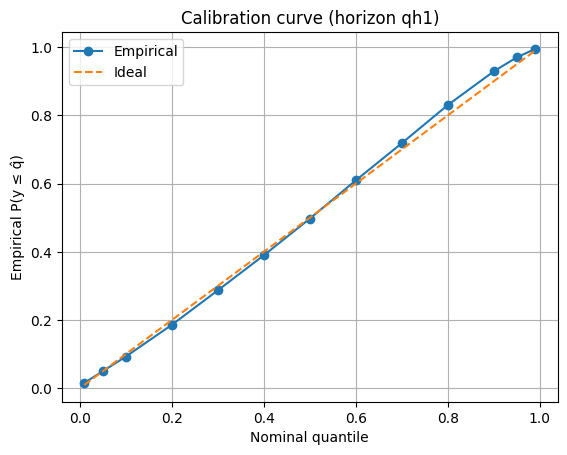

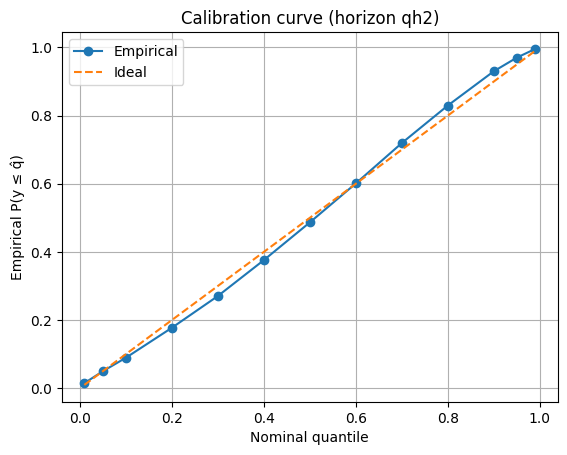

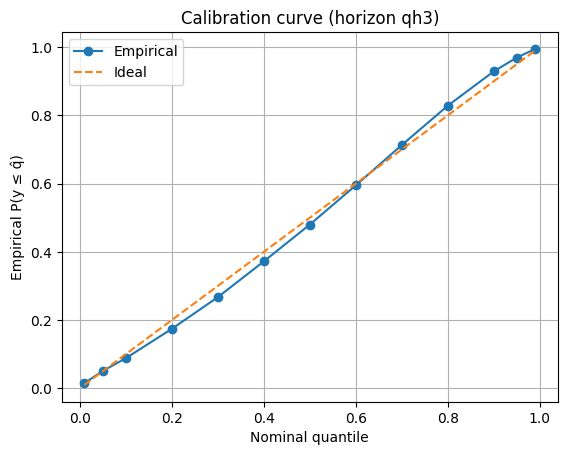

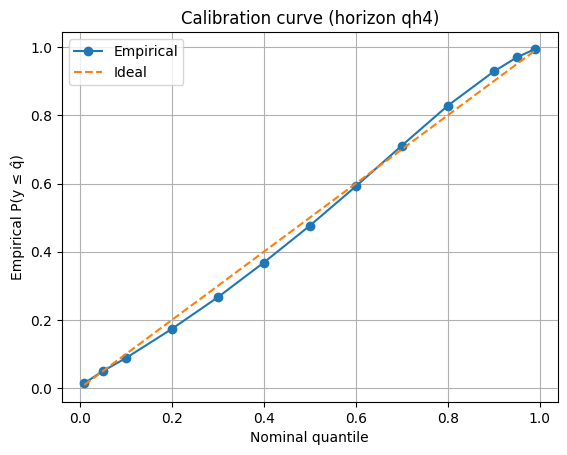

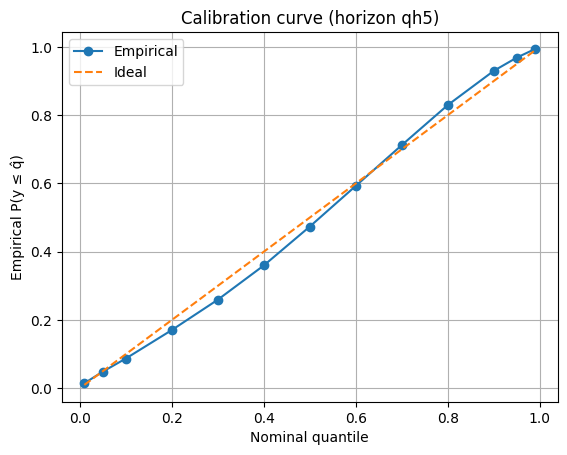

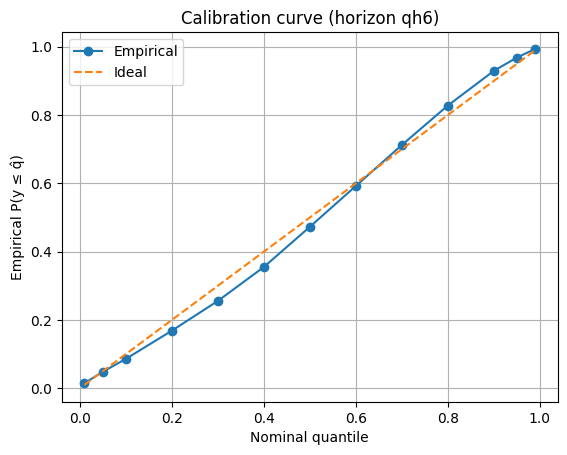

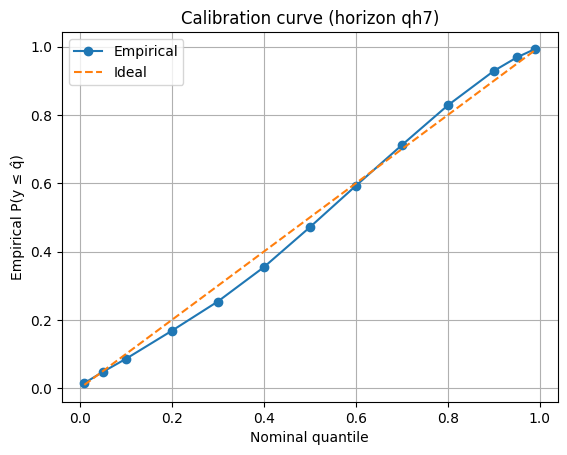

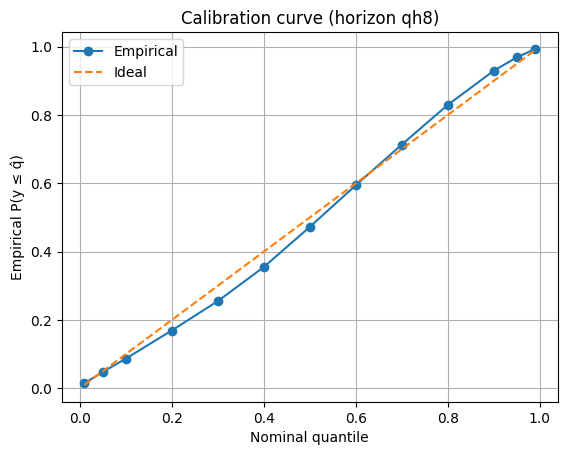

In [ ]:
# Calibration curve for a chosen horizon
plot_calibration_curve(prob_out["calibration"], horizon=1)

plot_calibration_curve(prob_out["calibration"], horizon=8)